In [1]:
import numpy as np

In [2]:
from PIL import Image
M = np.array(Image.open("anh.jpg").convert("L"), dtype=float)
print(M.shape)

(2000, 3000)


In [5]:
X = M.reshape(1,-1)
print("X.shape:", X.shape)

X.shape: (1, 6000000)


In [9]:
X_mean = X.mean(axis=0)
print(f"Shape of X before: {X.shape}")
print(f"Shape of X_mean: {X_mean.shape}")
X_centered= X - X_mean
print(f"shape of X after: {X_centered.shape}")


Shape of X before: (1, 6000000)
Shape of X_mean: (6000000,)
shape of X after: (1, 6000000)


In [24]:
def cosine_similarity(X, Y =None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

In [20]:
image_files = ["anh.jpg", "anh2.jpg", "anh3.jpg", "anh4.jpg"]
resizestat = (2000,3000)
X_list= []
for file in image_files:
    img = Image.open(file).convert("L")
    img_resized = img.resize(resizestat)
    N = np.array(img_resized, dtype = float)
    X_list.append(N.flatten())
    X = np.array(X_list)
    print(X.shape)

(1, 6000000)
(2, 6000000)
(3, 6000000)
(4, 6000000)


In [22]:
def search(query, top_k=3):
    img_q = Image.open(query).convert("L")
    img_qresized = img_q.resize(resizestat)
    M_q = np.array(img_qresized, dtype=float)
    q_vec = M_q.reshape(1,-1)
    sims = cosine_similarity(X, q_vec).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    for i in idx:
        name = image_files[i]
        point = sims[i]
        print(f"Top {list(idx).index(i) + 1}: {name} (Similarity: {point})")
        
    


In [72]:
sim_matrix = cosine_similarity(X)
n= sim_matrix.shape[0]
max_sim=-2
min_sim=2
most_sim = ()
least_sim = ()
for i in range(n):
    for j in range(i+1,n):
        point = sim_matrix[i,j]
        if point > max_sim:
            max_sim = point
            most_sim = (i,j)
        if point < min_sim:
            min_sim = point
            least_sim = (i,j)
print(f"most sim pair: {image_files[most_sim[0]]} and {image_files[most_sim[1]]}")
print(f"least sim pair: {image_files[least_sim[0]]} and {image_files[least_sim[1]]}")


most sim pair: anh.jpg and anh4.jpg
least sim pair: anh.jpg and anh3.jpg


# Nhận Xét
Kết quả của em khớp với trực giác

In [52]:
import matplotlib.pyplot as plt
square = np.array([[0,1,1,0,0],
                   [0,0,1,1,0]])
theta = np.radians(45)
R = np.array([[np.cos(theta), - np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])
S = np.array([[0.5, 0],
              [0, 1.5]])
rotated_square = R @ square
scaled_square = S @ square


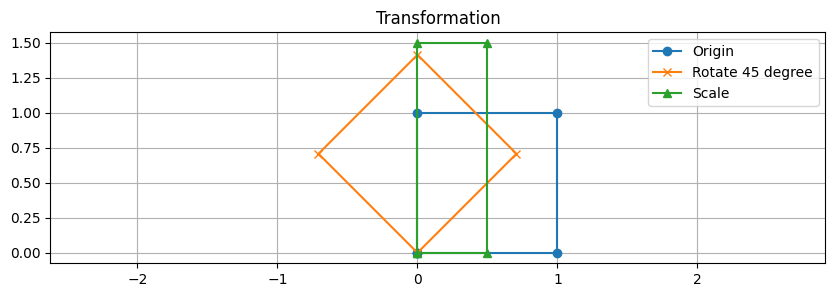

In [57]:
plt.figure(figsize=(10, 3))
plt.plot(square[0], square[1], label="Origin", marker='o')
plt.plot(rotated_square[0], rotated_square[1], label="Rotate 45 degree", marker='x')
plt.plot(scaled_square[0], scaled_square[1], label="Scale", marker='^')
plt.axis('equal')
plt.legend()
plt.title("Transformation")
plt.grid(True)
plt.show()

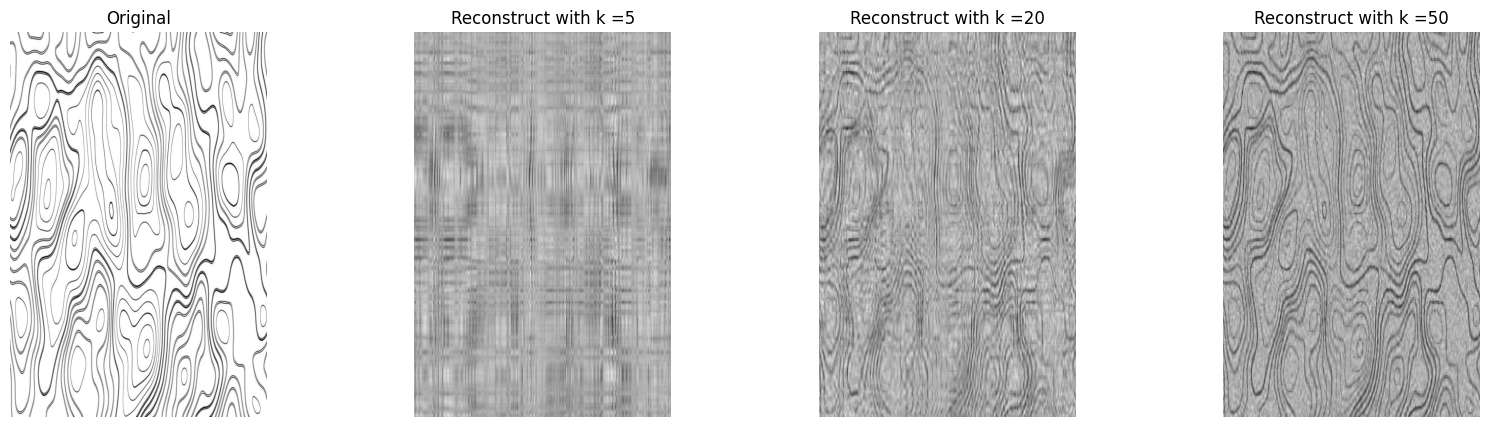

In [67]:
U, S, Vt = np.linalg.svd(M, full_matrices=False)
def reconstruct(k):
    return (U[:, :k] * S[:k] @ Vt[:k, :])
k_values = [5,20,50]
fig, axes = plt.subplots(1, 4, figsize=(20,5))
axes[0].imshow(M, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
for i, k in enumerate(k_values):
    img_reconstructed = reconstruct(k)
    axes[i+1].imshow(img_reconstructed, cmap='gray')
    axes[i+1].set_title(f"Reconstruct with k ={k}")
    axes[i+1].axis('off')
plt.show()

In [64]:
H, W = M.shape
original_size = H * W
max_k = min(H, W)
k_values_eval = [1, 5, 10, 20, 50, 100, 200]
k_values_eval = [k for k in k_values_eval if k <= max_k]
compression_ratios = []
reconstruction_errors = []
for k in k_values_eval:
    compressed_size = k * (H + W + 1)
    ratio = original_size / compressed_size
    compression_ratios.append(ratio)
    M_k = (U[:, :k] * S[:k]) @ Vt[:k, :]
    error = np.linalg.norm(M - M_k, ord='fro')
    reconstruction_errors.append(error)
    print(f"k = {k:<5} | {ratio:<13.2f}x | {error:<20.2f}")

k = 1     | 1199.76      x | 149032.22           
k = 5     | 239.95       x | 143101.22           
k = 10    | 119.98       x | 137200.73           
k = 20    | 59.99        x | 127219.27           
k = 50    | 24.00        x | 104603.56           
k = 100   | 12.00        x | 81536.31            
k = 200   | 6.00         x | 54377.95            


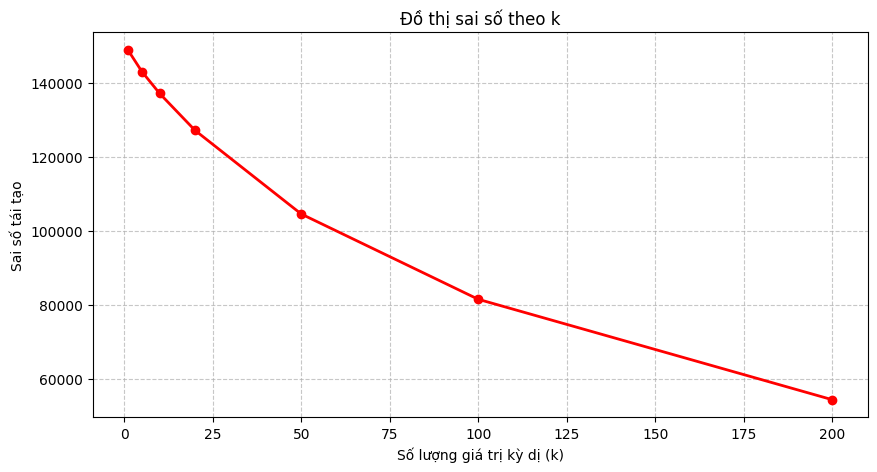

In [69]:
plt.figure(figsize=(10, 5))
plt.plot(k_values_eval, reconstruction_errors, marker='o', color='red', linestyle='-', linewidth=2)
plt.title("Đồ thị sai số theo k")
plt.xlabel("Số lượng giá trị kỳ dị (k)")
plt.ylabel("Sai số tái tạo")
plt.grid(True, linestyle='--', alpha=0.7)


# Nhận xét:
- Từ khoảng 10% đến 20\% số lượng giá trị kỳ dị thì bức ảnh tái tạo đã đủ rõ ràng để mắt người có thể nhận diện
- Giảm chiều dữ liệu giúp ma trận đầu vào nhỏ gọn hơn, làm cho mô hình AI tính toán nhanh hơn
- Nén dữ liệu giúp tiết kiệm tài nguyên và làm giảm dung lượng lưu trữ